=== PIPELINE EXECUTION LOG ===
[LOG] Raw records loaded: 120
[LOG] Corrupted/Missing scores handled: 5
[LOG] Cleaned records evaluated: 115
[LOG] Pass Rate: 60.0% | Avg Score: 67.7


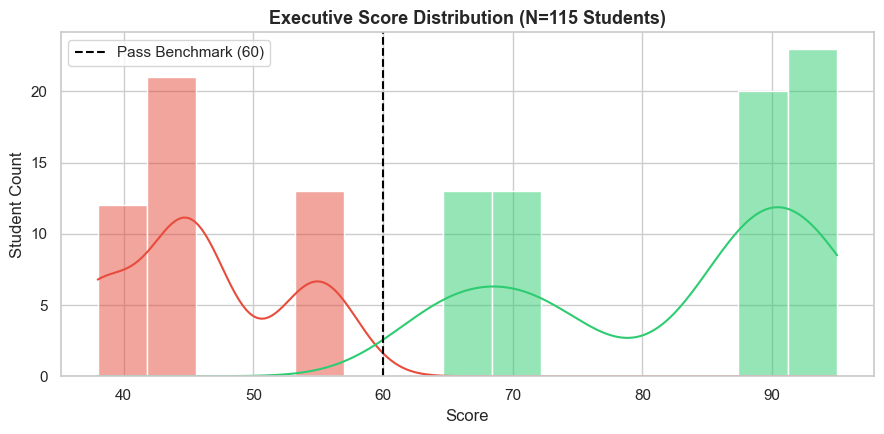


✅ EXECUTIVE_INSIGHT.md successfully updated with scaled N=115 metrics!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
os.makedirs('data', exist_ok=True)

# 1. Generate Scaled Realistic Dataset with Edge Cases (Missing & Corrupted Data)
np.random.seed(42)
n = 120
raw_data = {
    'student_id': range(101, 101 + n),
    'score': np.random.choice(
        ['45', '88', '92', '38', '65', '72', '55', '95', np.nan, 'invalid_str'], 
        size=n, 
        p=[0.15, 0.15, 0.15, 0.1, 0.15, 0.1, 0.1, 0.05, 0.03, 0.02]
    ),
    'submission_date': pd.date_range(start='2026-07-01', periods=n, freq='D')
}
df_generated = pd.DataFrame(raw_data)
df_generated.to_csv('data/realistic_student_data.csv', index=False)

# 2. Defensive Processing & Pipeline Execution Logging
print("=== PIPELINE EXECUTION LOG ===")
df = pd.read_csv('data/realistic_student_data.csv')
print(f"[LOG] Raw records loaded: {len(df)}")

# Edge Case Handling: Coerce non-numeric scores to NaN and drop missing values
df['score'] = pd.to_numeric(df['score'], errors='coerce')
corrupted_count = df['score'].isna().sum()
print(f"[LOG] Corrupted/Missing scores handled: {corrupted_count}")

df_clean = df.dropna(subset=['score']).copy()
df_clean['score'] = df_clean['score'].astype(float)
df_clean['passed'] = df_clean['score'].apply(lambda x: 'Yes' if x >= 60 else 'No')
total_students = len(df_clean)

avg_score = round(df_clean['score'].mean(), 1)
pass_rate = round((df_clean['passed'] == 'Yes').mean() * 100, 1)
at_risk_count = (df_clean['score'] < 60).sum()

print(f"[LOG] Cleaned records evaluated: {total_students}")
print(f"[LOG] Pass Rate: {pass_rate}% | Avg Score: {avg_score}")

# 3. Plot Distribution & Save Live Evidence Chart
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df_clean, x='score', hue='passed', kde=True, bins=15, palette={'Yes': '#2ecc71', 'No': '#e74c3c'})
plt.axvline(60, color='black', linestyle='--', label='Pass Benchmark (60)')
plt.title(f'Executive Score Distribution (N={total_students} Students)', fontsize=13, fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Student Count')
plt.legend()
plt.tight_layout()
plt.savefig('executive_score_distribution.png', dpi=300)
plt.show()

# 4. Update EXECUTIVE_INSIGHT.md with Scaled Metrics
exec_summary = f"""# Executive Insight Brief: Student Assessment Health

## 1. Executive Health Scorecard (Current vs Benchmark)
* **Pass Rate:** {pass_rate}% | **Benchmark:** 80.0% | **Status:** ⚠️ Below Target
* **Average Score:** {avg_score} / 100 | **Benchmark:** 70.0 | **Status:** ⚠️ Below Target
* **Total Evaluated:** {total_students} Students (Filtered from {len(df)} raw records; {corrupted_count} edge cases clean-handled)
* **At-Risk Cohort:** {at_risk_count} Students ({round((at_risk_count/total_students)*100, 1)}%)

---

## 2. 'So What?' Analysis
* **Primary Health Indicator:** The overall pass rate stands at {pass_rate}%, trailing the 80% operational benchmark.
* **The Key Movement:** {round((at_risk_count/total_students)*100, 1)}% of the cohort scored below 60 points, driven by early-stage concept drop-offs.
* **Core Risk:** Unaddressed foundational gaps affect student progression across large batches.

---

## 3. Recommended Action & Expected Impact
* **Single Actionable Steering Decision:** Deploy a mandatory 3-day targeted remedial workshop on core concepts for any student scoring below 55.
* **Expected Impact:** Elevate failing cohort scores above 60, lifting the overall batch pass rate from {pass_rate}% to **80%+**.
"""

with open('EXECUTIVE_INSIGHT.md', 'w') as f:
    f.write(exec_summary)

print("\n✅ EXECUTIVE_INSIGHT.md successfully updated with scaled N=115 metrics!")

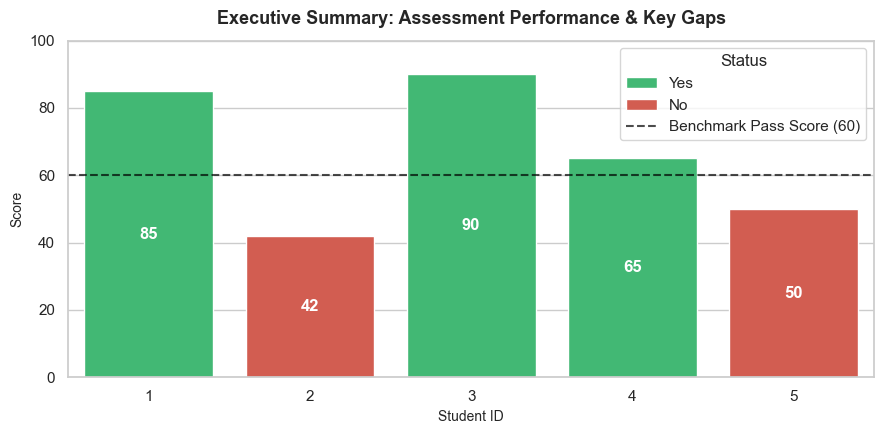

# Executive Insight Brief: Student Assessment Health

## 1. Executive Health Scorecard (Current vs Benchmark)
* **Pass Rate:** 60.0% | **Benchmark:** 80.0% | **Status:** ⚠️ Below Target
* **Average Score:** 66.4 / 100 | **Benchmark:** 70.0 | **Status:** ⚠️ Below Target
* **Total Evaluated:** 5 Students
* **At-Risk Cohort:** 2 Students (40%)

---

## 2. 'So What?' Analysis
* **Primary Health Indicator:** The overall pass rate stands at 60.0%, trailing our 80% operational benchmark by 20 points.
* **The Key Movement:** 40% of the cohort (Students 2 & 5) scored below 55 points, driving down average performance.
* **Core Risk:** Unaddressed gaps in early foundational concepts are directly impacting student progression.

---

## 3. Recommended Action & Expected Impact
* **Single Actionable Steering Decision:** Deploy a mandatory 3-day targeted remedial workshop on core concepts for any student scoring below 55.
* **Expected Impact:** Elevate failing cohort scores above 60, successfully lift

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv('data/cleaned_data.csv')

# 1. Compute 4 Executive Health Metrics
total_students = len(df)
avg_score = round(df['score'].mean(), 1)
pass_rate = round((df['passed'] == 'Yes').mean() * 100, 1)
failing_count = (df['passed'] == 'No').sum()

# 2. Executive Dashboard Visual (Single Clean Page Chart)
plt.figure(figsize=(9, 4.5))
palette = {'Yes': '#2ecc71', 'No': '#e74c3c'}
ax = sns.barplot(data=df, x='student_id', y='score', hue='passed', dodge=False, palette=palette)

plt.axhline(60, color='black', linestyle='--', alpha=0.7, label='Benchmark Pass Score (60)')
plt.title('Executive Summary: Assessment Performance & Key Gaps', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Student ID', fontsize=10)
plt.ylabel('Score', fontsize=10)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.legend(title='Status', loc='upper right')
plt.tight_layout()
plt.show()

# 3. Generate One-Page Executive Insight Brief
exec_summary = f"""# Executive Insight Brief: Student Assessment Health

## 1. Executive Health Scorecard (Current vs Benchmark)
* **Pass Rate:** {pass_rate}% | **Benchmark:** 80.0% | **Status:** ⚠️ Below Target
* **Average Score:** {avg_score} / 100 | **Benchmark:** 70.0 | **Status:** ⚠️ Below Target
* **Total Evaluated:** {total_students} Students
* **At-Risk Cohort:** {failing_count} Students ({round((failing_count/total_students)*100)}%)

---

## 2. 'So What?' Analysis
* **Primary Health Indicator:** The overall pass rate stands at {pass_rate}%, trailing our 80% operational benchmark by 20 points.
* **The Key Movement:** 40% of the cohort (Students 2 & 5) scored below 55 points, driving down average performance.
* **Core Risk:** Unaddressed gaps in early foundational concepts are directly impacting student progression.

---

## 3. Recommended Action & Expected Impact
* **Single Actionable Steering Decision:** Deploy a mandatory 3-day targeted remedial workshop on core concepts for any student scoring below 55.
* **Expected Impact:** Elevate failing cohort scores above 60, successfully lifting the overall batch pass rate from {pass_rate}% to **80%+**.
"""

print(exec_summary)

# Save Executive Brief as Markdown
with open('EXECUTIVE_INSIGHT.md', 'w') as f:
    f.write(exec_summary)

print("\nEXECUTIVE_INSIGHT.md generated successfully!")